In [2]:
import pickle 
import numpy as np
import matplotlib.pyplot as plt

In [3]:
save_path = "/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/internals_dict.pkl"
with open(save_path, 'rb') as f:
    internals_dict = pickle.load(f)

print(internals_dict.keys())

dict_keys(['dend_list_EC', 'an_velocity', 'dist', 'kernel', 'dt_constant'])


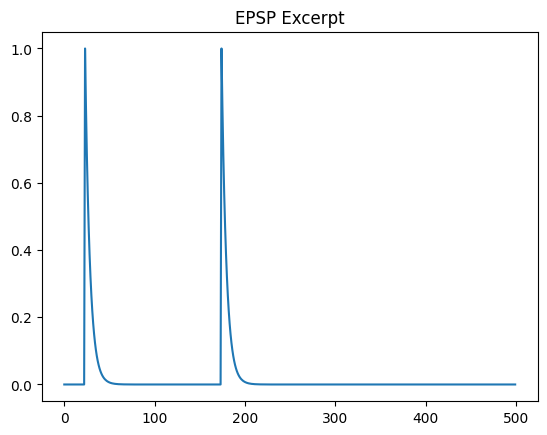

In [ ]:
def _sanitize_velocity_cm_s(v_in_m_per_s, min_vel_cm_s=1e-3 * 100):
    """
    Convert m/s -> cm/s and make strictly positive.
    Accepts 1D (n_pos,) or 2D (n_pos, n_trials). Returns same shape.
    Fills NaNs/<=0 by interpolation along the position axis, per trial.
    """

    v = np.asarray(v_in_m_per_s, dtype=np.float32) * np.float32(100.0)  # m/s -> cm/s

    def _sanitize_1d(x):
        # operate on the passed slice, not on the outer 'v'
        bad = ~np.isfinite(x) | (x <= 0)
        if bad.any():
            good_idx = np.flatnonzero(~bad)
            bad_idx  = np.flatnonzero(bad)
            if good_idx.size >= 2:
                x[bad] = np.interp(bad_idx, good_idx, x[good_idx])
            elif good_idx.size == 1:
                x[bad] = x[good_idx[0]]
            else:
                x[:] = np.float32(10.0)  # fallback if everything is bad
        return np.maximum(x, np.float32(min_vel_cm_s))

    if v.ndim == 1:
        return _sanitize_1d(v)
    if v.ndim == 2:
        out = v.copy()
        for t in range(out.shape[1]):
            out[:, t] = _sanitize_1d(out[:, t])
        return out
    raise ValueError(f"sanitize_velocity_cm_s: expected 1D or 2D, got shape {v.shape}")


def sample_weights(distribution, n_EC, n_dendrites, rng, mean=0.1, std=0.5):

    if distribution == "Uniform":
        samples = rng.uniform(low=mean - std, high=mean + std, size=(n_EC, n_dendrites))
    elif distribution == "Normal":
        samples = rng.normal(loc=mean, scale=std, size=(n_EC, n_dendrites))
        samples = np.clip(samples, 0, None)
    elif distribution == "Lognormal":
        # samples = rng.lognormal(mean=np.log(mean), sigma=std, size=n_samples)
        samples = rng.lognormal(mean=mean, sigma=std, size=(n_EC, n_dendrites))
    elif distribution == "Equal":
        samples = np.full((n_EC, n_dendrites), mean, dtype=float)
    else:
        raise ValueError("Invalid distribution")

    return samples


def get_inhom_poisson_spike_times_by_thinning(rate, t, dt=0.02, refractory=3., generator=None, rng=None):
    """
    Given a time series of instantaneous spike rates in Hz, produce a spike train consistent with an inhomogeneous
    Poisson process with a refractory period after each spike.
    :param rate: instantaneous rates in time (Hz)
    :param t: corresponding time values (ms)
    :param dt: temporal resolution for spike times (ms)
    :param refractory: absolute deadtime following a spike (ms)
    :param generator: :class:'random.Random()'
    :return: list of m spike times (ms)
    """
    if generator is None:
        generator = rng
    interp_t = np.arange(t[0], t[-1] + dt, dt)
    interp_rate = np.interp(interp_t, t, rate)
    interp_rate /= 1000.
    non_zero = np.where(interp_rate > 0.)[0]
    interp_rate[non_zero] = 1. / (1. / interp_rate[non_zero] - refractory)
    spike_times = []
    max_rate = np.max(interp_rate)
    i = 0
    ISI_memory = 0.
    while i < len(interp_t):
        x = generator.random()
        if x > 0.:
            ISI = -np.log(x) / max_rate
            i += int(ISI / dt)
            ISI_memory += ISI
            if (i < len(interp_t)) and (generator.random() <= interp_rate[i] / max_rate) and ISI_memory >= 0.:
                spike_times.append(interp_t[i])
                ISI_memory = -refractory
    return np.array(spike_times)


def epsps_event_add(spike_idx, T, kernel):
    """
    Exact causal conv with `kernel` using event-driven accumulation.
    spike_idx: 1D int array of spike times (samples)
    T: length of output trace
    kernel: 1D float array (causal; length K)
    returns: 1D float array of length T
    """
    out = np.zeros(T, dtype=np.float32)
    K = kernel.shape[0]
    for s in spike_idx:
        if 0 <= s < T:
            end = min(T, s + K)
            out[s:end] += kernel[:(end - s)]
    return out


def activity_to_dend_vm_2d(
    A_trials_time,
    Vrest=-70.0,
    vm_scale=0.1,
    center_across="time",   # "time" | "time_trials" | "none"
    dtype=np.float32):
    """
    A_trials_time: (n_trials, T) activity (may contain NaNs)
    Returns:
      Vm: (n_trials, T) in mV
      A_centered: centered activity (same shape)
      mu: the mean(s) removed (scalar or array)
    """
    A = np.asarray(A_trials_time, dtype=dtype, order="C")
    if A.ndim != 2:
        raise ValueError(f"A must be 2D (trials, time); got {A.shape}")

    if center_across == "time":
        # per-trial time mean -> each trial mean becomes Vrest after scaling/offset
        mu = np.nanmean(A, axis=1, keepdims=True).astype(dtype, copy=False)
    elif center_across == "time_trials":
        # single global mean over all trials and time
        mu = np.nanmean(A, keepdims=True).astype(dtype, copy=False)
    elif center_across == "none":
        mu = dtype(0.0)
    else:
        raise ValueError("center_across must be 'time', 'time_trials', or 'none'")

    A_centered = (A - mu).astype(dtype, copy=False)
    Vm = dtype(Vrest) + dtype(vm_scale) * A_centered
    return Vm, A_centered, (mu if np.isscalar(mu) else mu.astype(dtype, copy=False))



def turn_rates_into_spikes(dend_list_EC, an_velocity, dist, kernel, dt_constant=None, n_dendrites=100, rng=None, debug=False, optimization_time=None, mean=None, std=None):

    # if optimization_time:
    assert dt_constant is not None
    dt_ms = float(dt_constant * 1000.0)

    EC_input_matrix = np.stack(dend_list_EC, axis=0).astype(np.float32, copy=False)
    n_EC, n_pos, n_trials = EC_input_matrix.shape

    dx = np.float32(180.0 / n_pos)

    weights_EC = sample_weights(dist, n_EC, n_dendrites, rng=rng, mean=mean, std=std).astype(np.float32, copy=False)

    kernel = np.asarray(kernel, dtype=np.float32)

    L_prev = 1200  
    last_EPSP = None
    dend_vm_list = []  
    if debug:
        proc_peak_start = _get_peak_rss_bytes()

    if not optimization_time:
        warped_list = []

    for t in range(n_trials):
        if debug:
            trial_wall_start = time.perf_counter()
            trial_peak_before = _get_peak_rss_bytes()
            trial_curr_before = _get_current_rss_bytes()


        v_cm_s = _sanitize_velocity_cm_s(an_velocity[:, t]).astype(np.float32, copy=False)  # (n_pos,)
        dt_s   = dx / v_cm_s                                                                 # (n_pos,)
        time_points = np.cumsum(dt_s, dtype=np.float32)                                      # len n_pos
        total_time  = float(time_points[-1])
        t_axis = np.arange(0.0, total_time, float(dt_constant), dtype=np.float32)           # (T,)
        T = t_axis.size

        rows = np.empty((n_EC, T), dtype=np.float32)
        firing0 = EC_input_matrix[0, :, t].astype(np.float32, copy=False)
        valid0  = np.isfinite(firing0)
        warped0 = (np.interp(t_axis, time_points[valid0], firing0[valid0])
                if valid0.sum() >= 2 else np.full(1, np.nan, dtype=np.float32))
        warped0 = warped0.astype(np.float32, copy=False)
        holder = warped0[-L_prev:] if warped0.size >= L_prev else warped0

        two_len = len(holder) + T + len(holder)
        two_track_length = np.empty(two_len, dtype=np.float32)
        t_idx = np.arange(two_len, dtype=np.int32)

        if not optimization_time:
            warped_array = np.empty((n_EC, T), dtype=np.float32)

        for cell in range(n_EC):
            firing = EC_input_matrix[cell, :, t].astype(np.float32, copy=False)
            valid  = np.isfinite(firing)
            if valid.sum() >= 2:
                warped = np.interp(t_axis, time_points[valid], firing[valid]).astype(np.float32, copy=False)
            else:
                warped = np.full(1, np.nan, dtype=np.float32)

            hL = len(holder)
            two_track_length[:hL] = holder
            two_track_length[hL:hL + warped.size] = warped
            two_track_length[hL + warped.size:] = holder

            holder = warped[-L_prev:] if warped.size >= L_prev else warped

            spike_times = get_inhom_poisson_spike_times_by_thinning(two_track_length, t_idx, dt=dt_ms, refractory=3., generator=None, rng=rng).astype(np.int32, copy=False)

            epsps = epsps_event_add(spike_times, two_len, kernel).astype(np.float32, copy=False)
            epsps = epsps[hL:hL + T]  

            rows[cell, :] = epsps.astype(np.float32, copy=False)
            if not optimization_time:
                warped_array[cell, :] = warped

            last_EPSP = epsps  

        dend_vm_over_time = (weights_EC.astype(np.float32, copy=False).T @ rows.astype(np.float32, copy=False)).astype(np.float32, copy=False)  # (n_dendrites, T)

        dend_vm_list.append(dend_vm_over_time)

        if (t & 7) == 7:
            import gc; gc.collect()

        if not optimization_time:
            warped_list.append(warped_array.astype(np.float32, copy=False))

        if debug:
            trial_wall_end = time.perf_counter()
            trial_peak_after = _get_peak_rss_bytes()
            trial_curr_after = _get_current_rss_bytes()
            trial_peak_delta = None if (trial_peak_before is None or trial_peak_after is None) \
                else (trial_peak_after - trial_peak_before)
            proc_peak_since_start = None if (proc_peak_start is None or trial_peak_after is None) \
                else (trial_peak_after - proc_peak_start)
            print(
                f"trial {t:02d}:  time={trial_wall_end - trial_wall_start:6.3f}s  "
                f"RSS now={_fmt_bytes(trial_curr_after)}  "
                f"trial peak Δ={_fmt_bytes(trial_peak_delta)}  "
                f"proc peak={_fmt_bytes(trial_peak_after)}  "
                f"(+{_fmt_bytes(proc_peak_since_start)} since start)"
            )

        del rows, two_track_length, warped0, warped, firing, firing0

    num_trials = len(dend_vm_list)
    n_dendrites_ = dend_vm_list[0].shape[0]
    max_T = max(arr.shape[1] for arr in dend_vm_list)

    dend_vm_padded = np.full((num_trials, n_dendrites_, max_T), np.nan, dtype=np.float32)
    for i, arr in enumerate(dend_vm_list):
        Ti = arr.shape[1]
        dend_vm_padded[i, :, :Ti] = arr

    dend_contribution_EC = dend_vm_padded  # (trials, dendrites, time) f16

    if dend_contribution_EC.shape[1] != 100:
        print("dend_contribution_EC dendrites in the wrong axis")

    Vm_dict = {}
    for d in range(dend_contribution_EC.shape[1]):
        vm_array = dend_contribution_EC[:, d, :].astype(np.float32, copy=False)
        Vm, _, _ = activity_to_dend_vm_2d(vm_array, Vrest=-70.0, vm_scale=0.1, center_across="time")
        Vm_dict[d] = Vm.astype(np.float32, copy=False)

    dend_activity = np.stack([Vm_dict[k] for k in sorted(Vm_dict.keys())], axis=0).astype(np.float32, copy=False)

    if not optimization_time:
        return dend_activity, weights_EC, last_EPSP, warped_list, dend_vm_padded, dend_activity
    else:
        return dend_activity, weights_EC, last_EPSP
    

rng = np.random.default_rng(seed=42)


dend_activity, weights_EC, last_EPSP, warped_list, dend_vm_padded, dend_normalized = turn_rates_into_spikes(internals_dict["dend_list_EC"], internals_dict["an_velocity"], internals_dict["dist"], internals_dict["kernel"], dt_constant=internals_dict["dt_constant"], n_dendrites=100, rng=rng, debug=False, optimization_time=False, mean=0.5, std=1.0)


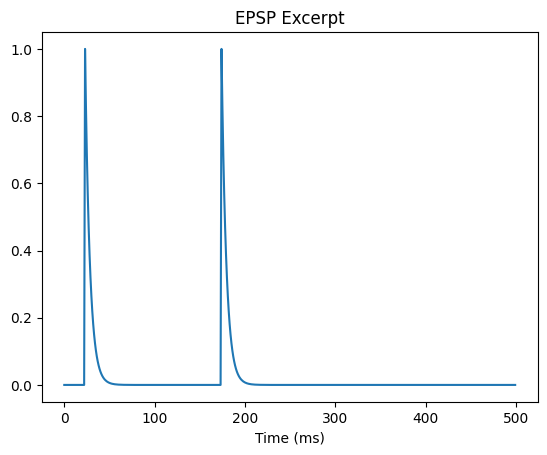

In [9]:

plt.plot(last_EPSP[:500])
plt.title("EPSP Excerpt")
plt.xlabel("Time (ms)")
plt.show()

(58, 100, 4187)


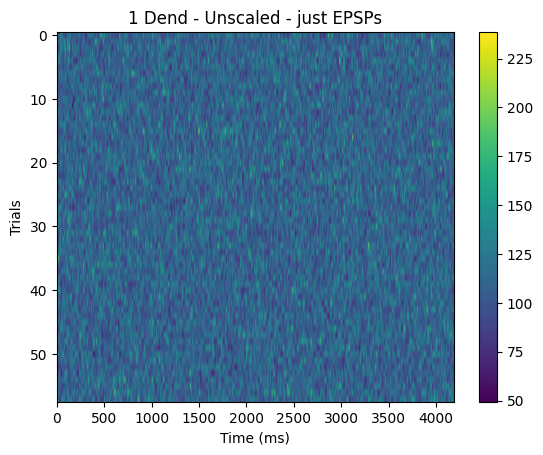

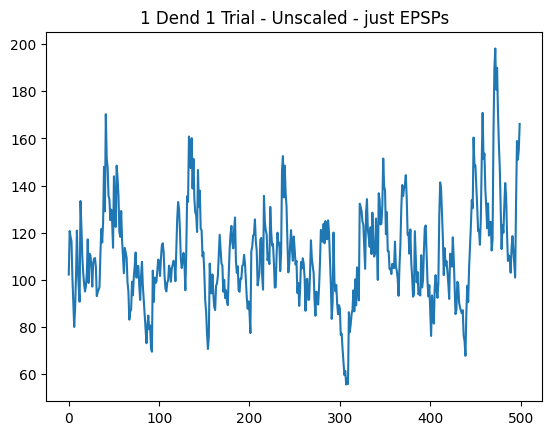

In [16]:
def plot_internals(dend_vm_padded, scaled=False):
    print(dend_vm_padded.shape)

    plt.imshow(dend_vm_padded[:,0,:], aspect='auto')
    plt.colorbar()
    plt.ylabel("Trials")
    plt.xlabel("Time (ms)")
    plt.title("1 Dend - Unscaled - just EPSPs")
    plt.show()

    plt.plot(dend_vm_padded[0,0,:500])
    if not scaled:
        plt.title("1 Dend 1 Trial - Unscaled - just EPSPs")
    else:
        plt.title("1 Dend 1 Trial Scaled Trial Mean -70")
    plt.show()

plot_internals(dend_vm_padded, scaled=False)

(58, 100, 4187)


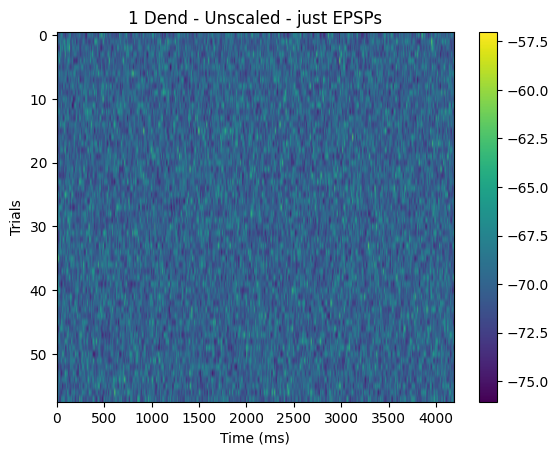

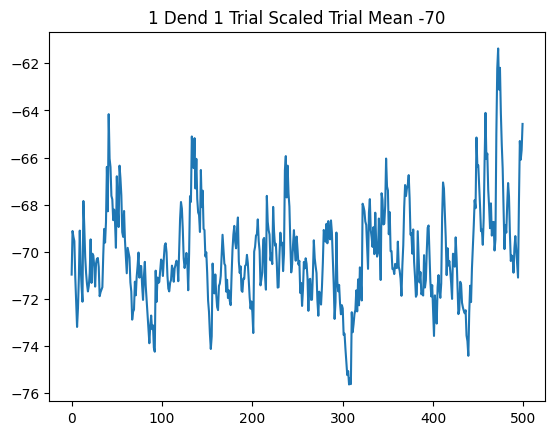

In [17]:
dend_normalized_transposed = np.transpose(dend_normalized, (1, 0, 2))
plot_internals(dend_normalized_transposed, scaled=True)

In [ ]:
save_path2 = "/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/warped_pkl.pkl"

with open(save_path2, 'rb') as f:
    warped = pickle.load(f)

warped_list = warped[0]



(792, 3927)

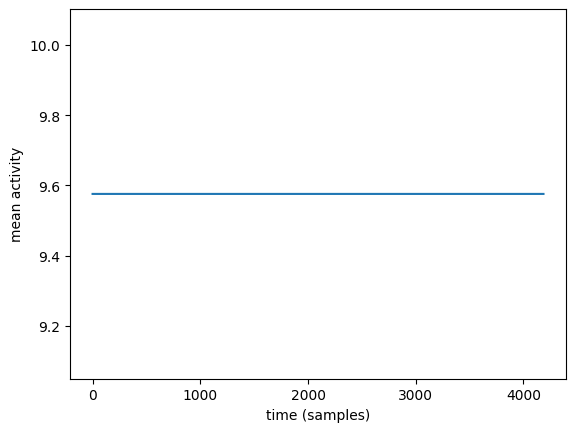

In [31]:
# each warped_array_trial has shape (N, T_trial)
max_T = max(a.shape[1] for a in warped_list)
max_N = max(a.shape[0] for a in warped_list)

padded = np.full((len(warped_list), max_T, max_N), np.nan, dtype=float)

for i, a in enumerate(warped_list):
    N, T = a.shape
    padded[i, :T, :N] = a.T   # transpose to (T, N) and place into padded slice

# mean over trials and neurons → time trace
mean_array = np.nanmean(padded, axis=(0, 2))   # shape (max_T,)

plt.plot(mean_array)
plt.xlabel("time (samples)")
plt.ylabel("mean activity")
plt.show()


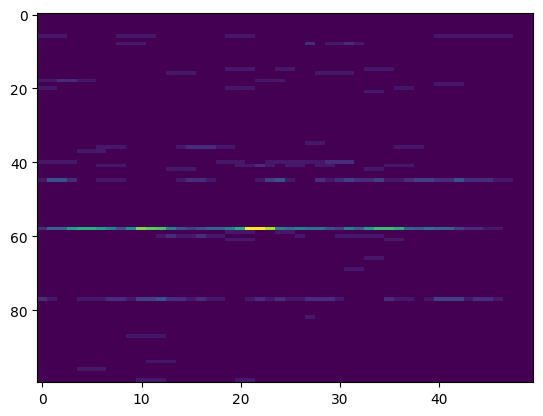

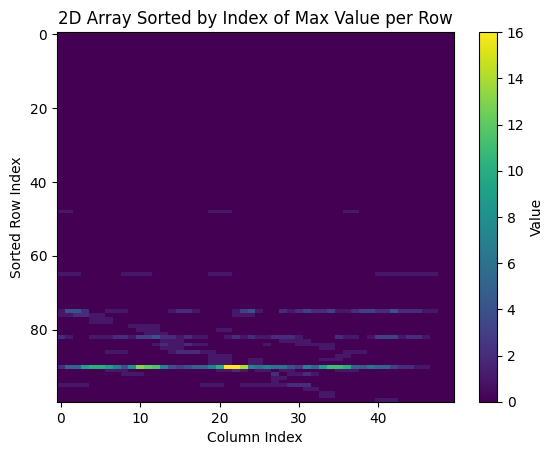

In [48]:
save_path_vel = "/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/an_vel_pkl.pkl"

save_path_plat = "/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/plat_array.pkl"

with open(save_path_plat, 'rb') as f:
    plat = pickle.load(f)


with open(save_path_vel, 'rb') as f:
    vel = pickle.load(f)

plateau_array = plat[0]



def get_interpolated_array(plat, vel, var=True):

    plat_array_per_dendrite = []

    if var:
        for dendrite in range(plat.shape[0]):

            plateau_array = plat[dendrite,:,:]

            plateau_pos_list = []

            for t in range(plateau_array.shape[0]):
                sig_time_full = plateau_array[t].astype(float)
                valid = np.isfinite(sig_time_full)
                if not np.any(valid):
                    plat_pos = np.full(50, np.nan)  # no data
                    plateau_pos_list.append(plat_pos)
                    continue

                last = np.max(np.where(valid)[0])
                sig_time = sig_time_full[:last+1]
                T       = sig_time.size
                t_ms    = np.arange(T, dtype=np.float32)
                # sig_time = plateau_array[t]                 # shape (T,), 0/1 per ms
                v        = vel[:, t]                        # shape (50,), m/s per position bin
                dx_m     = 1.8 / 50.0                       # meters per bin
                dt_ms    = 1.0
                # T        = sig_time.size

                dt_per_bin_ms = (dx_m / np.maximum(v, 1e-6)) * 1000.0              # (50,)
                dt_per_bin_ms *= (T*dt_ms) / np.sum(dt_per_bin_ms)

                edges_ms   = np.concatenate([[0.0], np.cumsum(dt_per_bin_ms)])     # (51,)
                centers_ms = 0.5 * (edges_ms[:-1] + edges_ms[1:])                  # (50,)

                t_ms = np.arange(T, dtype=np.float32) * dt_ms                      # (T,)

                plat_pos = np.interp(centers_ms, t_ms, sig_time)                   # (50,)

                plateau_pos_list.append(plat_pos)

            plateau_pos_array = np.stack(plateau_pos_list)

            plat_array_per_dendrite.append(plateau_pos_array)

        return plat_array_per_dendrite

    else:

        for dendrite in range(len(plat)):

            plateau_array = plat[dendrite]

            plateau_pos_list = []

            for t in range(plateau_array.shape[0]):
                sig_time = plateau_array[t]                 # shape (T,), 0/1 per ms
                v        = vel[:, t]                        # shape (50,), m/s per position bin
                dx_m     = 1.8 / 50.0                       # meters per bin
                dt_ms    = 1.0
                T        = sig_time.size

                dt_per_bin_ms = (dx_m / np.maximum(v, 1e-6)) * 1000.0              # (50,)
                dt_per_bin_ms *= (T*dt_ms) / np.sum(dt_per_bin_ms)

                edges_ms   = np.concatenate([[0.0], np.cumsum(dt_per_bin_ms)])     # (51,)
                centers_ms = 0.5 * (edges_ms[:-1] + edges_ms[1:])                  # (50,)

                t_ms = np.arange(T, dtype=np.float32) * dt_ms                      # (T,)

                plat_pos = np.interp(centers_ms, t_ms, sig_time)                   # (50,)

                plateau_pos_list.append(plat_pos)

            plateau_pos_array = np.stack(plateau_pos_list)

            plat_array_per_dendrite.append(plateau_pos_array)

        return plat_array_per_dendrite

plat_array_per_dendrite = get_interpolated_array(plat, vel, var=False)

plat_array_per_dendrite_array = np.stack(plat_array_per_dendrite)
sum_over_dends = np.sum(plat_array_per_dendrite_array, axis=1)

plt.imshow(sum_over_dends, aspect='auto')
plt.show()


max_indices = np.argmax(sum_over_dends, axis=1)
sorted_row_indices = np.argsort(max_indices)
sorted_sum_over_dends = sum_over_dends[sorted_row_indices, :]

plt.imshow(sorted_sum_over_dends, cmap='viridis', aspect='auto')
plt.colorbar(label='Value')
plt.title('2D Array Sorted by Index of Max Value per Row')
plt.xlabel('Column Index')
plt.ylabel('Sorted Row Index')
plt.show()


dend_activity_dict[0].shape (100, 58, 5581)
len(mean_var_per_array) 50


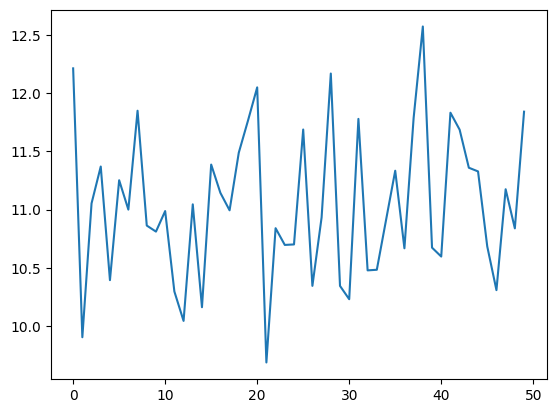

In [49]:
save_path3 = "/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/dend_activity_dict.pkl"
with open(save_path3, 'rb') as f:
    dend_activity_dict = pickle.load(f)

save_path_4 = "/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/an_vel_pkl.pkl"
with open(save_path_4, 'rb') as f:
    an_velocity = pickle.load(f)


print(f"dend_activity_dict[0].shape {dend_activity_dict[0].shape}")


dend_array = get_interpolated_array(dend_activity_dict[0], an_velocity, var=True)

stacked_dend = np.stack(dend_array)
stacked_dend.shape

var_per_cell = []

for cell in range(stacked_dend.shape[0]):
    dendrite = stacked_dend[cell,:,:]
    var_trials = np.var(dendrite, axis=0)
    var_per_cell.append(var_trials)

var_per_array = np.array(var_per_cell)

mean_var_per_array = np.nanmean(var_per_array, axis=0)
plt.plot(mean_var_per_array)

print(f"len(mean_var_per_array) {len(mean_var_per_array)}")
